## from AI remake of cross spectral analysis

In [1]:

"""
Multitaper coherence analysis between latitude bands of meridional heat
transport (MHT).

Python port of the MATLAB/jLab multitaper coherence workflow, adapted to
compare time series *between latitude bands* of a single xarray.DataArray
(dims: lat, time) rather than between two different data sources.

"""

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.signal.windows import dpss


from process_raw_data import process_data, decimal_year_to_datetime


## load data

In [2]:
ds = xr.open_dataset("data/Bayesian_estimates_Atlantic_MHT_HTC_HF_OHC.nc")

lats = ds.latitude.values
n_lats = len(lats)
lat_labels = [f"{np.abs(lat)}{'°N' if lat > 0 else '°S'}" for lat in lats]

ds["time"] = decimal_year_to_datetime(ds.time.values)

mht = ds.mht.isel(lat=slice(1,None)).dropna(dim="time", how="any") # drop 65
mht_mean = mht.mean(dim="posterior_samples")
mht_filtered = process_data(mht_mean)


In [3]:

# adapt lats to drop 65
lats = lats[1:]  # drop 65
lat_labels = lat_labels[1:]  # drop 65
n_lats = len(lats)

In [4]:



# ---------------------------------------------------------------------------
# Core multitaper coherence function
# ---------------------------------------------------------------------------

def multitaper_coherence(x, y, dt=1.0, p=2):
    """
    Multitaper magnitude-squared coherence and phase between two real,
    equally-spaced time series of the same length.

    Parameters
    ----------
    x, y : 1D array-like, same length
        The two time series to compare (NaNs not supported - drop/interp
        them first).
    dt : float
        Sample interval, in whatever time unit you want the period axis
        expressed in (e.g. 1.0 = "per time step"; if your steps are months,
        the resulting period axis will be in months).
    p : float
        Time-bandwidth product. Number of tapers used = 2p - 1. Larger p
        smooths the spectrum more but blurs together nearby frequencies;
        for short series (few tapers) is usually safer.

    Returns
    -------
    freq   : 1D array, frequency (cycles per unit time)
    period : 1D array, 1/freq (same units as dt); period[0] is inf/NaN
             (zero frequency)
    coh2   : 1D array, magnitude-squared coherence (0-1) at each frequency
    phase  : 1D array, phase in degrees. Positive means y leads x.
    gamma95: scalar, the coherence value above which coherence is
             considered significant at the 95% confidence level
             (Emery & Thomson formula), given the degrees of freedom
             implied by the number of tapers.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    assert x.shape == y.shape, "x and y must be the same length"
    assert not (np.isnan(x).any() or np.isnan(y).any()), \
        "NaNs present - drop or interpolate before calling this function"

    x = x - x.mean()
    y = y - y.mean()
    n = len(x)
    k = int(2 * p - 1)          # number of tapers
    tapers = dpss(n, p, k)      # shape (k, n)

    Xk = np.fft.rfft(tapers * x[None, :], axis=1)
    Yk = np.fft.rfft(tapers * y[None, :], axis=1)
    freq = np.fft.rfftfreq(n, d=dt)

    Sxx = np.mean(np.abs(Xk) ** 2, axis=0)
    Syy = np.mean(np.abs(Yk) ** 2, axis=0)
    Sxy = np.mean(Xk * np.conj(Yk), axis=0)

    coh2 = np.abs(Sxy) ** 2 / (Sxx * Syy)
    phase = np.degrees(np.arctan2(-np.imag(Sxy), np.real(Sxy)))

    dof = 2 * k
    gamma95 = 1 - 0.05 ** (2.0 / (dof - 2))

    period = np.full_like(freq, np.nan)
    nz = freq != 0
    period[nz] = 1.0 / freq[nz]

    return freq, period, coh2, phase, gamma95


# ---------------------------------------------------------------------------
# Helpers for working directly with your xarray DataArray
# ---------------------------------------------------------------------------

def infer_dt(mht):
    """
    Infer a sample interval from mht's time coordinate. Returns 1.0 if the
    time coordinate is already a plain integer/float index. If it's a
    datetime axis, returns the median spacing in days.
    """
    t = mht["time"].values
    if np.issubdtype(t.dtype, np.datetime64):
        diffs = np.diff(t).astype("timedelta64[s]").astype(float) / 86400.0
        return float(np.median(diffs))
    else:
        diffs = np.diff(t.astype(float))
        return float(np.median(diffs))


def _get_series(mht, idx, lat_dim="lat", posterior_dim="posterior_samples",
                 posterior_reduce="mean"):
    """
    Extract a single 1D time series for one latitude index, collapsing the
    posterior_samples dimension if present.

    posterior_reduce: "mean" or "median" -> collapse across posterior draws
                       to a single point-estimate time series (default).
                       int -> use that specific posterior sample index
                       instead of reducing (e.g. for spot-checking).
    If mht has no posterior_dim, this is a no-op and posterior_reduce is
    ignored.
    """
    da = mht.isel({lat_dim: idx})
    if posterior_dim in da.dims:
        if isinstance(posterior_reduce, (int, np.integer)):
            da = da.isel({posterior_dim: posterior_reduce})
        elif posterior_reduce == "median":
            da = da.median(dim=posterior_dim)
        else:
            da = da.mean(dim=posterior_dim)
    return da.values


def pairwise_coherence(mht, idx_pairs, p=2, dt=None, lat_dim="lat",
                        posterior_dim="posterior_samples",
                        posterior_reduce="mean"):
    """
    Compute multitaper coherence/phase for a list of (idx_a, idx_b)
    *index* pairs (positions along the lat dimension, e.g. from
    np.where(mask)[0]) drawn from an xarray.DataArray with dims
    (lat_dim, time[, posterior_dim]).

    Use this with .isel-style integer positions - NOT label values -
    since .sel requires an exact coordinate match which may not hold for
    your latitude coordinate (e.g. if the real degree values live in a
    separate variable like ds.latitude rather than being the lat
    coordinate itself).

    If mht has a posterior_samples dimension, posterior_reduce controls
    how it's collapsed before computing coherence: "mean" (default),
    "median", or a specific integer sample index. See
    pairwise_coherence_ensemble() below if you want coherence computed
    separately for every posterior draw (to get uncertainty bounds)
    instead of collapsing first.

    Returns a dict keyed by (idx_a, idx_b) with values
    {freq, period, coh2, phase, gamma95}.
    """
    if dt is None:
        dt = infer_dt(mht)

    results = {}
    for idx_a, idx_b in idx_pairs:
        x = _get_series(mht, idx_a, lat_dim, posterior_dim, posterior_reduce)
        y = _get_series(mht, idx_b, lat_dim, posterior_dim, posterior_reduce)
        freq, period, coh2, phase, gamma95 = multitaper_coherence(
            x, y, dt=dt, p=p
        )
        results[(idx_a, idx_b)] = dict(
            freq=freq, period=period, coh2=coh2, phase=phase, gamma95=gamma95
        )
    return results


def pairwise_coherence_ensemble(mht, idx_pairs, p=2, dt=None, lat_dim="lat",
                                 posterior_dim="posterior_samples",
                                 n_samples=200, random_state=0):
    """
    Like pairwise_coherence, but instead of collapsing posterior_samples to
    a point estimate first, computes coherence separately for a random
    subset of posterior draws (n_samples of them - using all 4000 is
    usually unnecessary and slow) and returns the distribution. This lets
    you see how much of your coherence estimate is driven by posterior
    uncertainty vs. a robust signal.

    Returns a dict keyed by (idx_a, idx_b) with values:
      {freq, period, gamma95,
       coh2_samples: array (n_samples, n_freq),
       coh2_median, coh2_lo (5th pct), coh2_hi (95th pct)}
    """
    if dt is None:
        dt = infer_dt(mht)
    rng = np.random.default_rng(random_state)

    n_total = mht.sizes[posterior_dim]
    sample_idx = rng.choice(n_total, size=min(n_samples, n_total), replace=False)

    results = {}
    for idx_a, idx_b in idx_pairs:
        coh2_stack = []
        freq = period = gamma95 = None
        for s in sample_idx:
            x = mht.isel({lat_dim: idx_a, posterior_dim: int(s)}).values
            y = mht.isel({lat_dim: idx_b, posterior_dim: int(s)}).values
            freq, period, coh2, _, gamma95 = multitaper_coherence(x, y, dt=dt, p=p)
            coh2_stack.append(coh2)
        coh2_stack = np.array(coh2_stack)  # (n_samples, n_freq)
        results[(idx_a, idx_b)] = dict(
            freq=freq, period=period, gamma95=gamma95,
            coh2_samples=coh2_stack,
            coh2_median=np.median(coh2_stack, axis=0),
            coh2_lo=np.percentile(coh2_stack, 5, axis=0),
            coh2_hi=np.percentile(coh2_stack, 95, axis=0),
        )
    return results


def plot_pair_ensemble(result, lat_a, lat_b, ax_coh=None):
    """Plot coherence median + 5-95% posterior range vs period."""
    if ax_coh is None:
        fig, ax_coh = plt.subplots(figsize=(7, 4))

    period = result["period"]
    med = result["coh2_median"]
    lo = result["coh2_lo"]
    hi = result["coh2_hi"]
    gamma95 = result["gamma95"]

    ax_coh.semilogx(period[1:], med[1:], ".-", label="posterior median")
    ax_coh.fill_between(period[1:], lo[1:], hi[1:], alpha=0.3,
                         label="posterior 5-95%")
    ax_coh.axhline(gamma95, color="r", linestyle="--", label="95% significance")
    ax_coh.set_ylabel("Coherence$^2$")
    ax_coh.set_xlabel("Period")
    ax_coh.set_title(f"{lat_a}\N{DEGREE SIGN} vs {lat_b}\N{DEGREE SIGN}")
    ax_coh.set_ylim(0, 1)
    ax_coh.grid(True, which="both", alpha=0.3)
    ax_coh.legend(loc="upper right", fontsize=8)
    return ax_coh


def coherence_profile(mht, ref_idx, idx_list, p=2, dt=None, lat_dim="lat",
                       posterior_dim="posterior_samples",
                       posterior_reduce="mean"):
    """
    Compute coherence & phase spectra for ONE reference latitude band
    against a list of other latitude bands (typically all bands). This is
    the data prep step for plot_coherence_profile, which plots it as a
    latitude x period map like a published-paper figure.

    idx_list should be the full set of bands you want as rows in the plot
    (it's fine to include ref_idx itself - that row will show coherence=1
    everywhere, same as the diagonal of the heatmap).

    Returns a dict:
      period : 1D array (n_freq,), in whatever units dt is in
      coh2   : 2D array (n_idx, n_freq)
      phase  : 2D array (n_idx, n_freq)
      gamma95: scalar significance threshold (same for every row, since
               they all use the same series length/tapers)
      idx_list: the idx_list you passed in, same order as rows of coh2/phase
    """
    if dt is None:
        dt = infer_dt(mht)
    x_ref = _get_series(mht, ref_idx, lat_dim, posterior_dim, posterior_reduce)

    coh_rows, phase_rows = [], []
    period = gamma95 = None
    for idx in idx_list:
        y = _get_series(mht, idx, lat_dim, posterior_dim, posterior_reduce)
        freq, period, coh2, phase, gamma95 = multitaper_coherence(
            x_ref, y, dt=dt, p=p
        )
        coh_rows.append(coh2)
        phase_rows.append(phase)

    return dict(period=period, coh2=np.array(coh_rows),
                phase=np.array(phase_rows), gamma95=gamma95,
                idx_list=list(idx_list))


def plot_coherence_profile(result, lat_values, ref_lat_label=None,
                            period_scale=1.0, mask_insignificant=True,
                            period_range=None, coh_vmin=0,
                            cmap_coh="plasma_r", cmap_phase="RdBu_r",
                            xticks=(1, 2, 3, 5, 10, 15, 20, 30)):
    """
    Plot coherence & phase of one reference band vs all others as two
    stacked latitude (y-axis) x period (x-axis) color maps, in the style
    of the published-figure example (coherence top, phase bottom, log
    period axis, insignificant regions masked white).

    result        : output of coherence_profile()
    lat_values    : actual latitude degree values, SAME ORDER as the
                    idx_list used when calling coherence_profile (e.g.
                    lats[idx_list])
    period_scale  : multiply the period axis by this factor to change
                    units, e.g. if dt is in days, use 1/365.25 to get
                    period in years (matching the reference figure)
    mask_insignificant : if True, coherence/phase below the 95%
                    significance threshold are shown as blank/white,
                    matching the reference figure
    period_range  : optional (min, max) tuple to zoom the x-axis
    xticks        : explicit tick locations on the (log-scale) period
                    axis, labeled as plain numbers (e.g. "1", "3", "10")
                    instead of matplotlib's default 10^x notation. Set to
                    None to fall back to default log-axis ticks. Values
                    outside your actual period range are silently ignored
                    by matplotlib.
    """
    from matplotlib.ticker import NullFormatter, FixedLocator, FixedFormatter

    period = result["period"] * period_scale
    coh2 = result["coh2"]      # (n_lat, n_freq)
    phase = result["phase"]
    gamma95 = result["gamma95"]
    lat_values = np.asarray(lat_values)

    assert coh2.shape[0] == len(lat_values), \
        "lat_values must match the idx_list order used in coherence_profile"

    # sort rows by latitude, north (top) to south (bottom), like the figure
    order = np.argsort(lat_values)[::-1]
    lat_sorted = lat_values[order]
    coh_sorted = coh2[order]
    phase_sorted = phase[order]

    if mask_insignificant:
        mask = coh_sorted < gamma95
        coh_plot = np.ma.masked_where(mask, coh_sorted)
        phase_plot = np.ma.masked_where(mask, phase_sorted)
    else:
        coh_plot = coh_sorted
        phase_plot = phase_sorted

    # drop the zero-frequency (infinite period) bin
    p0 = 1
    per = period[p0:]

    fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

    cmap1 = plt.get_cmap(cmap_coh).copy()
    cmap1.set_bad("white")
    im0 = axes[0].pcolormesh(per, lat_sorted, coh_plot[:, p0:], cmap=cmap1,
                              vmin=coh_vmin, vmax=1.0, shading="nearest")
    axes[0].set_xscale("log")
    axes[0].set_ylabel("Latitude")
    cb0 = fig.colorbar(im0, ax=axes[0])
    cb0.set_label("Coherence$^2$")

    cmap2 = plt.get_cmap(cmap_phase).copy()
    cmap2.set_bad("white")
    im1 = axes[1].pcolormesh(per, lat_sorted, phase_plot[:, p0:], cmap=cmap2,
                              vmin=-180, vmax=180, shading="nearest")
    axes[1].set_xscale("log")
    axes[1].set_xlabel("Period" + (" (years)" if period_scale != 1.0 else ""))
    axes[1].set_ylabel("Latitude")
    cb1 = fig.colorbar(im1, ax=axes[1])
    cb1.set_label("Phase (deg)")

    if xticks is not None:
        for ax in axes:
            ax.xaxis.set_major_locator(FixedLocator(xticks))
            ax.xaxis.set_major_formatter(FixedFormatter([str(t) for t in xticks]))
            ax.xaxis.set_minor_formatter(NullFormatter())  # no clutter between ticks

    if period_range is not None:
        axes[0].set_xlim(period_range)
        axes[1].set_xlim(period_range)

    if ref_lat_label is not None:
        fig.suptitle(f"Coherence / phase relative to {ref_lat_label}\N{DEGREE SIGN}")

    fig.tight_layout()
    return fig, axes


def all_pairs(indices):
    """All unique (i, j) index pairs, i < j, from a list/array of indices."""
    indices = list(indices)
    return [(indices[i], indices[j])
            for i in range(len(indices)) for j in range(i + 1, len(indices))]


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_pair(result, lat_a, lat_b, ax_coh=None, ax_phase=None):
    """
    Plot coherence and phase vs period for a single pair, jLab-style.
    lat_a, lat_b here are just labels for the title (e.g. actual latitude
    values in degrees) - pass whatever you want displayed, they don't need
    to match how the pair was selected.
    """
    if ax_coh is None or ax_phase is None:
        fig, (ax_coh, ax_phase) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

    period = result["period"]
    coh2 = result["coh2"]
    phase = result["phase"]
    gamma95 = result["gamma95"]

    ax_coh.semilogx(period[1:], coh2[1:], ".-")
    ax_coh.axhline(gamma95, color="r", linestyle="--", label="95% significance")
    ax_coh.set_ylabel("Coherence$^2$")
    ax_coh.set_title(f"{lat_a}\N{DEGREE SIGN} vs {lat_b}\N{DEGREE SIGN}")
    ax_coh.set_ylim(0, 1)
    ax_coh.grid(True, which="both", alpha=0.3)
    ax_coh.legend(loc="upper right", fontsize=8)

    ax_phase.semilogx(period[1:], phase[1:], ".-")
    ax_phase.set_xlabel("Period")
    ax_phase.set_ylabel("Phase (deg)")
    ax_phase.grid(True, which="both", alpha=0.3)

    return ax_coh, ax_phase


def coherence_heatmap(mht, idx_list, p=2, dt=None, period_of_interest=None,
                       reduce="max", lat_dim="lat",
                       posterior_dim="posterior_samples",
                       posterior_reduce="mean"):
    """
    Build an n x n matrix summarizing coherence across all pairs drawn from
    idx_list (integer positions along lat_dim - use e.g. np.arange(len(lats))
    for all bands, or block1_idx / block2_idx for a subset), either the
    coherence at a specific period (period_of_interest, nearest match) or a
    reduction (max/mean) over all resolved periods.

    reduce: "max" -> strongest coherence anywhere in the spectrum
            "mean" -> mean coherence across all resolved periods
    Returns a 2D numpy array (n x n), symmetric, diagonal = 1. Row/column
    order matches idx_list, not necessarily sorted latitude order.
    """
    idx_list = list(idx_list)
    n = len(idx_list)
    mat = np.full((n, n), np.nan)
    np.fill_diagonal(mat, 1.0)

    for i in range(n):
        for j in range(i + 1, n):
            x = _get_series(mht, idx_list[i], lat_dim, posterior_dim, posterior_reduce)
            y = _get_series(mht, idx_list[j], lat_dim, posterior_dim, posterior_reduce)
            _, period, coh2, _, _ = multitaper_coherence(
                x, y, dt=(dt or infer_dt(mht)), p=p
            )
            if period_of_interest is not None:
                idx = np.nanargmin(np.abs(period[1:] - period_of_interest)) + 1
                val = coh2[idx]
            elif reduce == "max":
                val = np.nanmax(coh2[1:])
            else:
                val = np.nanmean(coh2[1:])
            mat[i, j] = mat[j, i] = val

    return mat


def plot_heatmap(mat, lats, title="Coherence between latitude bands"):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(mat, vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(len(lats)))
    ax.set_yticks(range(len(lats)))
    ax.set_xticklabels([f"{l}\N{DEGREE SIGN}" for l in lats], rotation=45)
    ax.set_yticklabels([f"{l}\N{DEGREE SIGN}" for l in lats])
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="Coherence$^2$")
    for i in range(len(lats)):
        for j in range(len(lats)):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center",
                     color="white" if mat[i, j] < 0.6 else "black", fontsize=8)
    fig.tight_layout()
    return fig, ax



In [5]:
mht = mht_filtered
LAT_DIM = "lat"  # match your actual dim name


block1 = [35, 26, 16]
block2 = [5, -5, -11, -25, -35]

lat_block1 = (16, 35)
lat_block2 = (-35, 5)

blocks_idx = []

for lat_min, lat_max in [lat_block1, lat_block2]:  
    mask = (lats >= lat_min) & (lats <= lat_max)
    blocks_idx.append(np.where(mask)[0])
    
block1_idx, block2_idx = blocks_idx
 
# results_block1 = pairwise_coherence(mht, all_pairs(block1_idx))
# results_block2 = pairwise_coherence(mht, all_pairs(block2_idx))
# cross_results  = pairwise_coherence(mht, [(a, b) for a in block1 for b in block2])

# plot_pair(results_block1[(35, 26)], 35, 26)

# results_block1 = pairwise_coherence(mht, all_pairs(block1_idx), lat_dim=LAT_DIM)
# results_cross  = pairwise_coherence(mht, [(a,b) for a in block1_idx for b in block2_idx], lat_dim=LAT_DIM)

# i, j = 1,2 
# plot_pair(results_cross[(block1_idx[i], block2_idx[j])], lats[block1_idx[i]], lats[block2_idx[j]])


In [6]:
# all_idx = np.arange(len(lats)) 

# mat = coherence_heatmap(mht_filtered, all_idx, p=2, reduce="max", lat_dim="lat")
# plot_heatmap(mat, lats[all_idx], title="Max coherence² across all periods")


In [7]:
lats

array([ 60.,  55.,  45.,  35.,  26.,  16.,   5.,  -5., -11., -25., -35.])

(<Figure size 700x800 with 4 Axes>,
 array([<Axes: ylabel='Latitude'>,
        <Axes: xlabel='Period (years)', ylabel='Latitude'>], dtype=object))

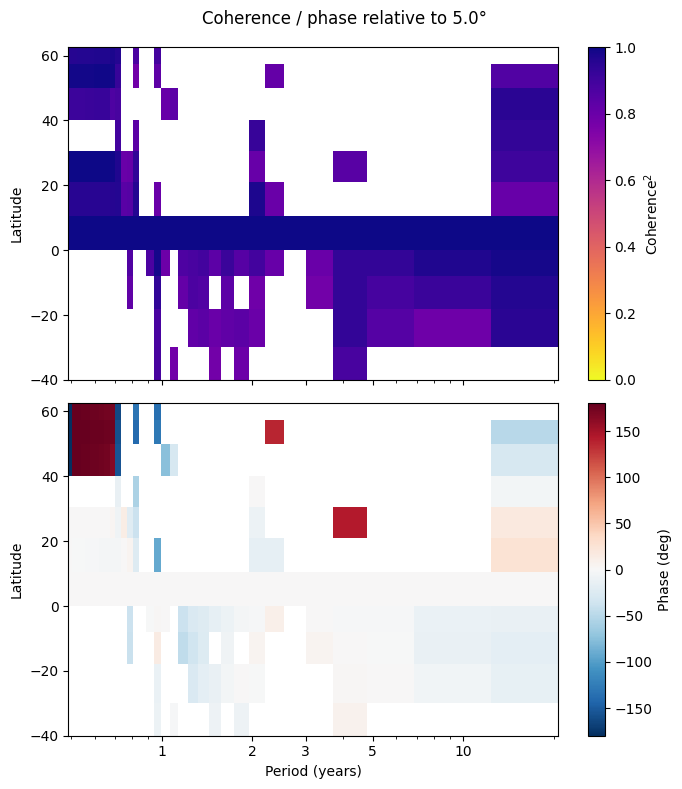

In [8]:

ref_idx = 6         # index of the latitude band you want as the "reference" (e.g. 35°N)
all_idx = np.arange(len(lats))   # all bands, or a subset

result = coherence_profile(mht, ref_idx, all_idx, p=2, lat_dim="lat")

plot_coherence_profile(
    result, lats[all_idx],
    ref_lat_label=lats[ref_idx],
    period_scale=1/365.25,          # if you want years
    xticks=(1, 2, 3, 5, 10) # tick locations, labeled as plain numbers
)

# plt.savefig("coherence_profile.png", dpi=150)